<a href="https://colab.research.google.com/github/nitinth001/Reinforcement_Learning/blob/main/SARSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
import numpy as np
import pickle as pkl

env = gym.make("CliffWalking-v1")

q_table = np.zeros((48,4))

def policy(state, explore):

    action = np.argmax(q_table[state])

    if np.random.random() <= explore:
        action = np.random.randint(0,4)

    return action


EPSILON = 0.1
ALPHA = 0.1
GAMMA = 0.9
NUM_EPISODES = 500


for q in range(NUM_EPISODES):

    done = False
    total_reward = 0
    episode_length = 0

    state, _ = env.reset()

    action = policy(state, EPSILON)

    while not done:

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_action = policy(next_state, EPSILON)

        q_table[state][action] += ALPHA * (
            reward + GAMMA * q_table[next_state][next_action]
            - q_table[state][action]
        )

        state = next_state
        action = next_action

        total_reward += reward
        episode_length += 1

    print("episode:", q,
          "total reward:", total_reward,
          "episode length:", episode_length)

env.close()

pkl.dump(q_table, open("q_table.pkl", "wb"))
print("Training DOne:")


episode: 0 total reward: -84 episode length: 84
episode: 1 total reward: -2566 episode length: 883
episode: 2 total reward: -387 episode length: 288
episode: 3 total reward: -313 episode length: 214
episode: 4 total reward: -417 episode length: 318
episode: 5 total reward: -623 episode length: 227
episode: 6 total reward: -294 episode length: 195
episode: 7 total reward: -111 episode length: 111
episode: 8 total reward: -109 episode length: 109
episode: 9 total reward: -314 episode length: 215
episode: 10 total reward: -101 episode length: 101
episode: 11 total reward: -315 episode length: 216
episode: 12 total reward: -63 episode length: 63
episode: 13 total reward: -358 episode length: 160
episode: 14 total reward: -55 episode length: 55
episode: 15 total reward: -222 episode length: 123
episode: 16 total reward: -80 episode length: 80
episode: 17 total reward: -567 episode length: 270
episode: 18 total reward: -39 episode length: 39
episode: 19 total reward: -71 episode length: 71
e

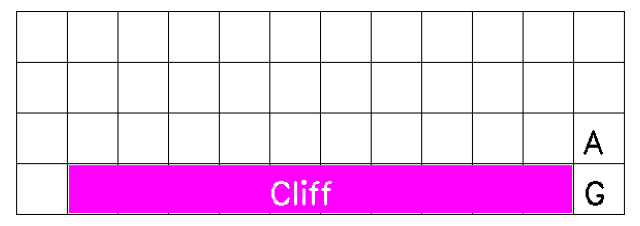

Episode: 4 Length: 15 Reward: -15


In [2]:
import gymnasium as gym
import cv2
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Create environment
cliffEnv = gym.make("CliffWalking-v1")

# Load Q-table
q_table = pkl.load(open("q_table.pkl", "rb"))


# --------- Visual Grid ----------
def initialize_frame():
    width, height = 600, 200
    img = np.ones((height, width, 3)) * 255.0

    margin_horizontal = 6
    margin_vertical = 2

    # Vertical lines
    for i in range(13):
        img = cv2.line(img, (49*i + margin_horizontal, margin_vertical),
                       (49*i + margin_horizontal, 200-margin_vertical),
                       (0,0,0), 1)

    # Horizontal lines
    for i in range(5):
        img = cv2.line(img, (margin_horizontal, 49*i + margin_vertical),
                       (600-margin_horizontal, 49*i + margin_vertical),
                       (0,0,0), 1)

    # Cliff
    img = cv2.rectangle(img,
                        (49*1 + margin_horizontal + 2, 49*3 + margin_vertical + 2),
                        (49*11 + margin_horizontal - 2, 49*4 + margin_vertical - 2),
                        (255,0,255), -1)

    img = cv2.putText(img, "Cliff",
                      (49*5 + margin_horizontal, 49*4 + margin_vertical - 10),
                      cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

    # Goal
    img = cv2.putText(img, "G",
                      (49*11 + margin_horizontal + 10, 49*4 + margin_vertical - 10),
                      cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

    return img


# --------- Put Agent ----------
def put_agent(img, state):

    margin_horizontal = 6
    margin_vertical = 2

    row, column = np.unravel_index(state, (4,12))

    cv2.putText(img, "A",
                (49*column + margin_horizontal + 10,
                 49*(row+1) + margin_vertical - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

    return img


# --------- Policy ----------
def policy(state, explore=0.0):

    action = int(np.argmax(q_table[state]))

    if np.random.random() <= explore:
        action = np.random.randint(0,4)

    return action


# --------- Run Episodes ----------
NUM_EPISODES = 5

for episode in range(NUM_EPISODES):

    done = False
    total_reward = 0
    episode_length = 0

    frame = initialize_frame()

    state, _ = cliffEnv.reset()

    while not done:

        frame2 = put_agent(frame.copy(), state)

        clear_output(wait=True)

        plt.figure(figsize=(8,3))
        plt.imshow(frame2.astype(np.uint8))
        plt.axis("off")
        plt.show()

        action = policy(state)

        next_state, reward, terminated, truncated, _ = cliffEnv.step(action)

        done = terminated or truncated
        state = next_state

        episode_length += 1
        total_reward += reward

        time.sleep(0.3)

    print("Episode:", episode,
          "Length:", episode_length,
          "Reward:", total_reward)

cliffEnv.close()

In [3]:
import gymnasium as gym
import numpy as np
import pickle as pkl

env = gym.make("CliffWalking-v1")

q_table = np.zeros((48,4))

ALPHA = 0.1
GAMMA = 0.9
EPSILON = 0.1
NUM_EPISODES = 500


def policy(state, explore):

    action = np.argmax(q_table[state])

    if np.random.random() <= explore:
        action = np.random.randint(0,4)

    return action


for episode in range(NUM_EPISODES):

    state, _ = env.reset()
    done = False

    total_reward = 0
    episode_length = 0

    while not done:

        action = policy(state, EPSILON)

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Q-Learning Update
        best_next_action = np.argmax(q_table[next_state])

        q_table[state][action] += ALPHA * (
            reward
            + GAMMA * q_table[next_state][best_next_action]
            - q_table[state][action]
        )

        state = next_state

        total_reward += reward
        episode_length += 1

    print("Episode:", episode,
          "Reward:", total_reward,
          "Length:", episode_length)


# Save Q table
pkl.dump(q_table, open("q_learning_q_table.pkl","wb"))

env.close()

Episode: 0 Reward: -131 Length: 131
Episode: 1 Reward: -2336 Length: 851
Episode: 2 Reward: -654 Length: 357
Episode: 3 Reward: -1174 Length: 481
Episode: 4 Reward: -367 Length: 268
Episode: 5 Reward: -649 Length: 253
Episode: 6 Reward: -268 Length: 169
Episode: 7 Reward: -102 Length: 102
Episode: 8 Reward: -646 Length: 349
Episode: 9 Reward: -234 Length: 135
Episode: 10 Reward: -78 Length: 78
Episode: 11 Reward: -136 Length: 136
Episode: 12 Reward: -215 Length: 116
Episode: 13 Reward: -170 Length: 71
Episode: 14 Reward: -93 Length: 93
Episode: 15 Reward: -212 Length: 113
Episode: 16 Reward: -340 Length: 142
Episode: 17 Reward: -97 Length: 97
Episode: 18 Reward: -299 Length: 101
Episode: 19 Reward: -64 Length: 64
Episode: 20 Reward: -68 Length: 68
Episode: 21 Reward: -85 Length: 85
Episode: 22 Reward: -225 Length: 126
Episode: 23 Reward: -152 Length: 53
Episode: 24 Reward: -76 Length: 76
Episode: 25 Reward: -48 Length: 48
Episode: 26 Reward: -77 Length: 77
Episode: 27 Reward: -489 Leng

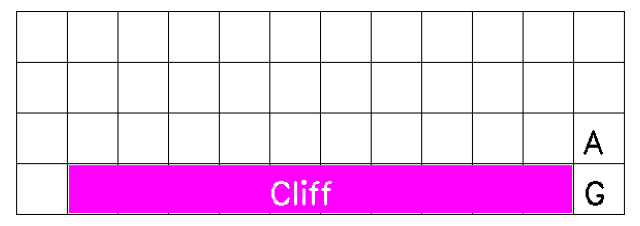

Episode: 4 Length: 13 Reward: -13


In [4]:
import gymnasium as gym
import cv2
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Create environment
cliffEnv = gym.make("CliffWalking-v1")

# Load Q-table
q_table = pkl.load(open("q_learning_q_table.pkl", "rb"))


# --------- Visual Grid ----------
def initialize_frame():
    width, height = 600, 200
    img = np.ones((height, width, 3)) * 255.0

    margin_horizontal = 6
    margin_vertical = 2

    # Vertical lines
    for i in range(13):
        img = cv2.line(img, (49*i + margin_horizontal, margin_vertical),
                       (49*i + margin_horizontal, 200-margin_vertical),
                       (0,0,0), 1)

    # Horizontal lines
    for i in range(5):
        img = cv2.line(img, (margin_horizontal, 49*i + margin_vertical),
                       (600-margin_horizontal, 49*i + margin_vertical),
                       (0,0,0), 1)

    # Cliff
    img = cv2.rectangle(img,
                        (49*1 + margin_horizontal + 2, 49*3 + margin_vertical + 2),
                        (49*11 + margin_horizontal - 2, 49*4 + margin_vertical - 2),
                        (255,0,255), -1)

    img = cv2.putText(img, "Cliff",
                      (49*5 + margin_horizontal, 49*4 + margin_vertical - 10),
                      cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

    # Goal
    img = cv2.putText(img, "G",
                      (49*11 + margin_horizontal + 10, 49*4 + margin_vertical - 10),
                      cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

    return img


# --------- Put Agent ----------
def put_agent(img, state):

    margin_horizontal = 6
    margin_vertical = 2

    row, column = np.unravel_index(state, (4,12))

    cv2.putText(img, "A",
                (49*column + margin_horizontal + 10,
                 49*(row+1) + margin_vertical - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

    return img


# --------- Policy ----------
def policy(state, explore=0.0):

    action = int(np.argmax(q_table[state]))

    if np.random.random() <= explore:
        action = np.random.randint(0,4)

    return action


# --------- Run Episodes ----------
NUM_EPISODES = 5

for episode in range(NUM_EPISODES):

    done = False
    total_reward = 0
    episode_length = 0

    frame = initialize_frame()

    state, _ = cliffEnv.reset()

    while not done:

        frame2 = put_agent(frame.copy(), state)

        clear_output(wait=True)

        plt.figure(figsize=(8,3))
        plt.imshow(frame2.astype(np.uint8))
        plt.axis("off")
        plt.show()

        action = policy(state)

        next_state, reward, terminated, truncated, _ = cliffEnv.step(action)

        done = terminated or truncated
        state = next_state

        episode_length += 1
        total_reward += reward

        time.sleep(0.3)

    print("Episode:", episode,
          "Length:", episode_length,
          "Reward:", total_reward)

cliffEnv.close()